<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/notebooks/hybrid_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations timm -q

print(True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm


In [ ]:
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
RESULTS      = '/content/drive/MyDrive/project/results'
MODELS       = '/content/drive/MyDrive/project/models'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'
]

CONFIG = {
    'image_size'  : 224,
    'batch_size'  : 32,
    'num_workers' : 2,
    'epochs'      : 3,
    'lr'          : 1e-4,
    'seed'        : 42,
    'num_classes' : 8,
    'mean'        : [0.485, 0.456, 0.406],
    'std'         : [0.229, 0.224, 0.225],
}

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Classes:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

Classes:
  0: Tomato_healthy
  1: Tomato_Bacterial_spot
  2: Tomato_Early_blight
  3: Tomato_Late_blight
  4: Tomato_Leaf_Mold
  5: Tomato_Septoria_leaf_spot
  6: Tomato_Spider_mites_Two_spotted_spider_mite
  7: Tomato__Tomato_YellowLeaf__Curl_Virus


In [ ]:
torch.manual_seed(CONFIG['seed'])

all_paths, all_labels = [], []

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(cls_path, img_file))
            all_labels.append(class_to_idx[cls])

print(f"Total images: {len(all_paths)}")
for idx, cls in idx_to_class.items():
    print(f"  {cls}: {all_labels.count(idx)}")

# Stratified split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=CONFIG['seed']
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50,
    stratify=temp_labels, random_state=CONFIG['seed']
)

print(f"\nTrain : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Total images: 14234
  Tomato_healthy: 1591
  Tomato_Bacterial_spot: 2127
  Tomato_Early_blight: 1000
  Tomato_Late_blight: 1909
  Tomato_Leaf_Mold: 952
  Tomato_Septoria_leaf_spot: 1771
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3208

Train : 9963
Val   : 2135
Test  : 2136


In [ ]:
train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("Transforms ready.")

Transforms ready.


/tmp/ipykernel_1370/204584386.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
/tmp/ipykernel_1370/204584386.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [ ]:
class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

train_dataset = TomatoDataset(train_paths, train_labels, train_transform)
val_dataset   = TomatoDataset(val_paths,   val_labels,   val_test_transform)
test_dataset  = TomatoDataset(test_paths,  test_labels,  val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 9963 | Val: 2135 | Test: 2136


In [ ]:
class_counts   = Counter(train_labels)
class_weights  = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = torch.tensor([class_weights[l] for l in train_labels], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          sampler=sampler, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'], pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 312
Val batches  : 67
Test batches : 67


In [ ]:
class MultiScaleStem(nn.Module):
    """
    Novelty 1 — Three parallel kernels capture disease features
    at multiple physical scales simultaneously.
    3x3 for bacterial spot (tiny lesions)
    5x5 for septoria (medium spots)
    7x7 for late blight (large patches)
    """
    def __init__(self):
        super().__init__()
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_7x7 = nn.Sequential(
            nn.Conv2d(3, 22, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(22), nn.ReLU()
        )
        # Compress concatenated 64ch back to 64ch
        self.compress = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )

    def forward(self, x):
        b3 = self.branch_3x3(x)
        b5 = self.branch_5x5(x)
        b7 = self.branch_7x7(x)
        out = torch.cat([b3, b5, b7], dim=1)  # 64 channels
        return self.compress(out)

print("MultiScaleStem defined.")

MultiScaleStem defined.


In [ ]:
class SEModule(nn.Module):
    """
    Novelty 2 — Channel attention that learns which feature
    channels represent true disease signal vs noise.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        weight = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * weight


class DepthwiseSeparableBlock(nn.Module):
    """
    Lightweight convolution block.
    8x fewer multiplications than standard conv.
    """
    def __init__(self, in_ch, out_ch, stride=2, use_se=False):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                      padding=1, groups=in_ch, bias=False),
            nn.GroupNorm(num_groups=min(32, in_ch), num_channels=in_ch),
            nn.ReLU()
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.GroupNorm(num_groups=min(32, out_ch), num_channels=out_ch),
            nn.ReLU()
        )
        self.se       = SEModule(out_ch) if use_se else nn.Identity()
        self.dropout  = nn.Dropout2d(0.1)

    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        x = self.se(x)
        return self.dropout(x)

print("SEModule and DepthwiseSeparableBlock defined.")

SEModule and DepthwiseSeparableBlock defined.


In [ ]:
class CNNBranch(nn.Module):
    """
    Full custom CNN branch with multi-scale stem,
    depthwise separable blocks, and SE attention.
    Output: 512-dim feature vector.
    """
    def __init__(self):
        super().__init__()
        self.stem   = MultiScaleStem()                              # 224x224x64
        self.block1 = DepthwiseSeparableBlock(64,  128, use_se=False)  # 112x112x128
        self.block2 = DepthwiseSeparableBlock(128, 256, use_se=True)   # 56x56x256
        self.block3 = DepthwiseSeparableBlock(256, 512, use_se=False)  # 28x28x512
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.flat   = nn.Flatten()

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.flat(x)   # 512-dim vector

print("CNNBranch defined.")

CNNBranch defined.


In [ ]:
class CAFormerBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.caformer = timm.create_model(
            'caformer_s18', pretrained=True, num_classes=0
        )

        # Freeze all first
        for param in self.caformer.parameters():
            param.requires_grad = False

        # Unfreeze Stage 4 fully
        for param in self.caformer.stages[3].parameters():
            param.requires_grad = True

        # Unfreeze last 2 blocks of Stage 3 only
        stage3_blocks = list(self.caformer.stages[2].blocks)
        for block in stage3_blocks[-2:]:
            for param in block.parameters():
                param.requires_grad = True

        # Unfreeze head norm if it exists
        if hasattr(self.caformer, 'head'):
            for param in self.caformer.head.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.caformer(x)

print("CAFormerBranch defined.")

CAFormerBranch defined.


In [ ]:
class CBSEF(nn.Module):
    """
    Novelty 3 — Cross-Branch Squeeze-Excitation Fusion.
    Instead of naive concatenation, an SE gate learns
    to dynamically weight CNN vs CAFormer features
    per disease class.
    """
    def __init__(self, feature_dim=1024, reduction=16):
        super().__init__()
        self.se_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(feature_dim // reduction, feature_dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, trans_feat):
        # Concatenate both 512-dim vectors → 1024-dim
        combined = torch.cat([cnn_feat, trans_feat], dim=1)
        # SE gate learns per-dimension weights
        gate     = self.se_gate(combined)
        gated    = combined * gate
        # Residual connection prevents information loss
        return gated + combined

print("CBSEF defined.")

CBSEF defined.


In [ ]:
class FullHybridModel(nn.Module):
    """
    Complete novel architecture:
    CNN Branch (multi-scale stem + SE) +
    CAFormer Branch (selective fine-tune) +
    CBSEF fusion +
    Classification head
    """
    def __init__(self, num_classes=8):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.trans_branch = CAFormerBranch()
        self.fusion       = CBSEF(feature_dim=1024, reduction=16)
        self.classifier   = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_feat   = self.cnn_branch(x)      # 512-dim
        trans_feat = self.trans_branch(x)    # 512-dim
        fused      = self.fusion(cnn_feat, trans_feat)  # 1024-dim
        return self.classifier(fused)        # 8-dim logits

model = FullHybridModel(num_classes=CONFIG['num_classes']).to(device)

# Parameter count
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters    : 23,830,648
Trainable parameters: 13,972,626


In [ ]:
# Weighted loss for class imbalance
counts      = [class_counts[i] for i in range(CONFIG['num_classes'])]
weights     = torch.tensor([1.0/c for c in counts], dtype=torch.float).to(device)
criterion   = nn.CrossEntropyLoss(weight=weights)

# Two param groups — lower lr for pretrained CAFormer
optimizer = optim.Adam([
    {'params': model.cnn_branch.parameters(),   'lr': CONFIG['lr']},
    {'params': model.fusion.parameters(),        'lr': CONFIG['lr']},
    {'params': model.classifier.parameters(),    'lr': CONFIG['lr']},
    {'params': filter(lambda p: p.requires_grad,
               model.trans_branch.parameters()), 'lr': CONFIG['lr'] * 0.1},
], lr=CONFIG['lr'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
)

print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [ ]:
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0

for epoch in range(CONFIG['epochs']):
    # Training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            val_loss += criterion(outputs, labels).item()
            preds    = outputs.argmax(dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'          : val_acc,
            'class_to_idx'     : class_to_idx,
            'config'           : CONFIG,
        }, os.path.join(MODELS, 'best_hybrid_model.pth'))

    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"Best: {best_val_acc:.2f}%")

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.2f}%")

Epoch 01/3 | Train Loss: 1.3413 | Val Loss: 0.5027 | Val Acc: 86.28% | Best: 86.28%
Epoch 02/3 | Train Loss: 0.7771 | Val Loss: 0.2787 | Val Acc: 92.74% | Best: 92.74%
Epoch 03/3 | Train Loss: 0.6218 | Val Loss: 0.2174 | Val Acc: 94.75% | Best: 94.75%

Training complete. Best Val Acc: 94.75%


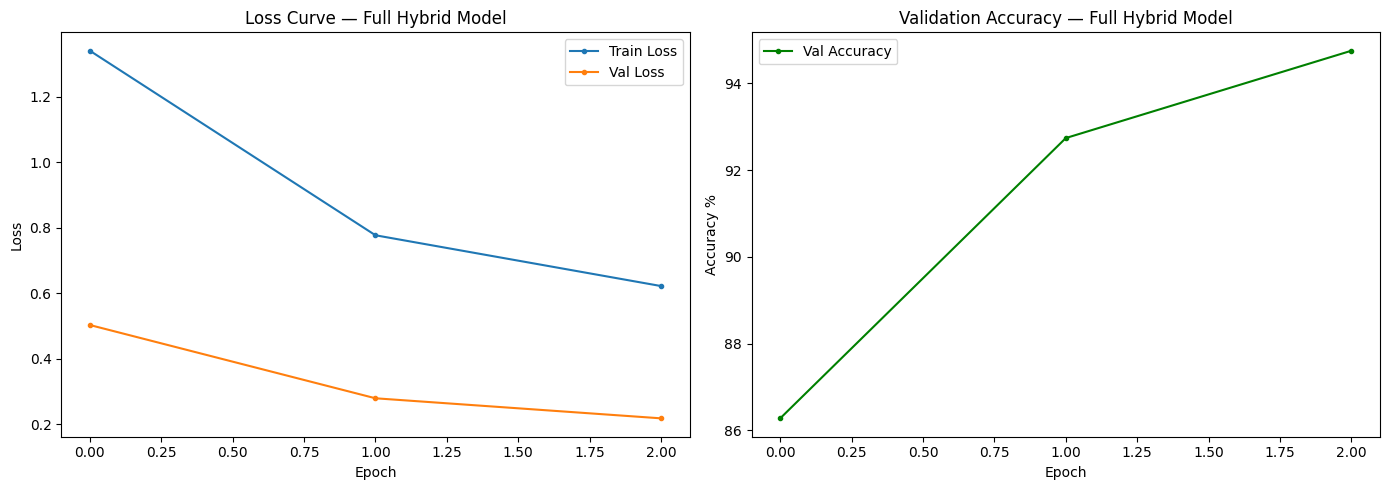

Saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', marker='o', markersize=3)
ax1.plot(val_losses,   label='Val Loss',   marker='o', markersize=3)
ax1.set_title('Loss Curve — Full Hybrid Model')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(val_accuracies, label='Val Accuracy', marker='o', markersize=3, color='green')
ax2.set_title('Validation Accuracy — Full Hybrid Model')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'hybrid_training_curves.png'), dpi=150)
plt.show()
print("Saved!")

                 precision    recall  f1-score   support

        healthy       0.96      0.99      0.98       238
 Bacterial spot       0.93      0.98      0.95       319
   Early blight       0.83      0.93      0.88       150
    Late blight       0.95      0.88      0.91       287
      Leaf Mold       0.94      1.00      0.97       143
Septoria leaf s       0.98      0.94      0.96       266
Spider mites Tw       0.95      0.98      0.96       251
 YellowLeaf  Cu       1.00      0.94      0.97       482

       accuracy                           0.95      2136
      macro avg       0.94      0.96      0.95      2136
   weighted avg       0.95      0.95      0.95      2136



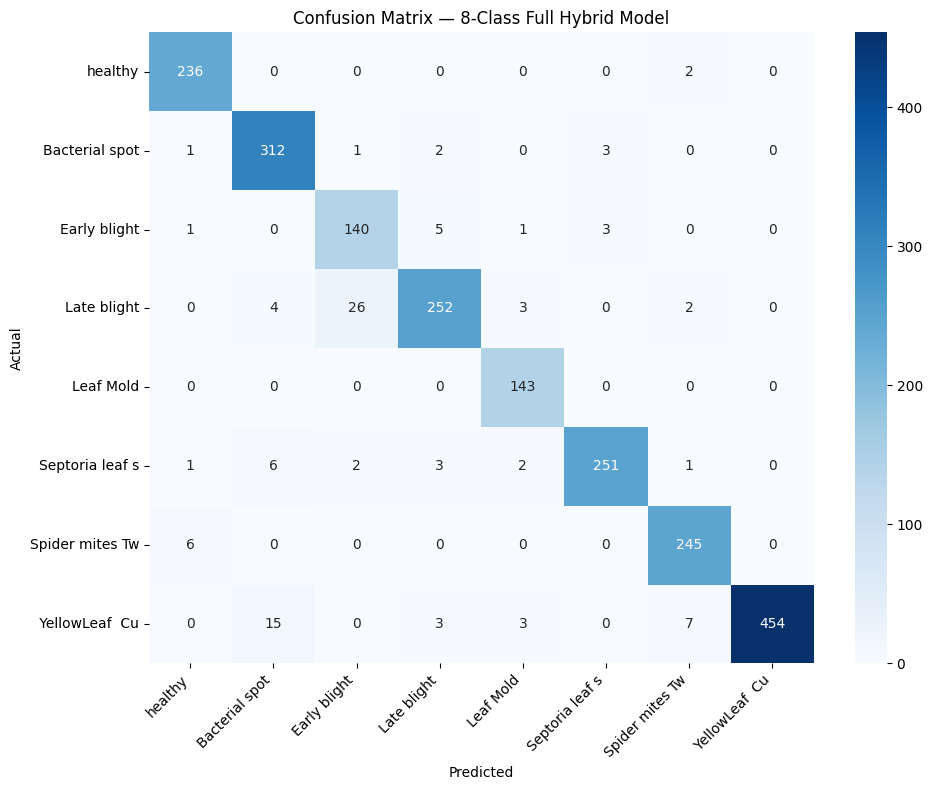

In [ ]:
# Load best saved model
checkpoint = torch.load(os.path.join(MODELS, 'best_hybrid_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
all_preds, all_labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

short_names = [idx_to_class[i].replace('Tomato_','').replace('_',' ')[:15] for i in range(8)]

print(classification_report(
    all_labels_list, all_preds, target_names=short_names
))

# Confusion matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix — 8-Class Full Hybrid Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'hybrid_confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
summary = {
    'best_val_accuracy' : best_val_acc,
    'total_params'      : total,
    'trainable_params'  : trainable,
    'classes'           : SELECTED_CLASSES,
    'epochs_trained'    : CONFIG['epochs'],
}

import json
with open(os.path.join(RESULTS, 'hybrid_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("Results summary saved!")
print(json.dumps(summary, indent=2))

Results summary saved!
{
  "best_val_accuracy": 94.75409836065573,
  "total_params": 2135,
  "trainable_params": 13972626,
  "classes": [
    "Tomato_healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Tomato_YellowLeaf__Curl_Virus"
  ],
  "epochs_trained": 3
}
